In [ ]:
!pip install -q transformers datasets seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import random
import numpy as np

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)

from seqeval.metrics import classification_report

In [ ]:
import torch
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Device: cuda


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

# 1) Download raw CoNLL-2003 files
!wget -q https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.train -O eng.train
!wget -q https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.testa -O eng.testa
!wget -q https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/eng.testb -O eng.testb
print("CoNLL-2003 downloaded")

CoNLL-2003 downloaded


In [ ]:
def parse_conll(filepath):
    sentences = []
    tokens = []
    nertags = []

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("-DOCSTART-") or line == "":
                if tokens:
                    sentences.append({"tokens": tokens, "ner_tags": nertags})
                    tokens, nertags = [], []
            else:
                parts = line.split()
                tokens.append(parts[0])
                nertags.append(parts[-1])  # last column is NER tag
    if tokens:
        sentences.append({"tokens": tokens, "ner_tags": nertags})
    return sentences

train_data = parse_conll("eng.train")
val_data   = parse_conll("eng.testa")
test_data  = parse_conll("eng.testb")

print("Train", len(train_data), "sentences")
print("Val", len(val_data), "sentences")
print("Test", len(test_data), "sentences")
print("Sample:", train_data[0]["tokens"], "\n", train_data[0]["ner_tags"])

Train 14041 sentences
Val 3250 sentences
Test 3453 sentences
Sample: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'] 
 ['I-ORG', 'O', 'I-MISC', 'O', 'O', 'O', 'I-MISC', 'O', 'O']


In [ ]:
all_labels = sorted({tag for item in train_data for tag in item["ner_tags"]})
label2id = {label: i for i, label in enumerate(all_labels)}
id2label = {i: label for label, i in label2id.items()}

print("Labels found:", all_labels)
print("Total label types:", len(all_labels))

Labels found: ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Total label types: 8


In [ ]:
# Build label mappings once
all_labels = sorted({tag for item in train_data for tag in item["ner_tags"]})

label_list = all_labels              # main ordered label list
num_labels = len(label_list)
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

print("Labels found:", label_list)
print("Total label types:", num_labels)

Labels found: ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Total label types: 8


In [ ]:
def to_hf_dataset(data):
    return Dataset.from_dict({
        "tokens": [d["tokens"] for d in data],
        "ner_tags": [[label2id[t] for t in d["ner_tags"]] for d in data],
    })

train_ds = to_hf_dataset(train_data)
val_ds   = to_hf_dataset(val_data)
test_ds  = to_hf_dataset(test_data)

conll = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

In [ ]:
from datasets import Dataset, DatasetDict

# 1) Label mappings (if you haven't already done this)
all_labels = sorted({tag for item in train_data for tag in item["ner_tags"]})
label2id = {label: i for i, label in enumerate(all_labels)}
id2label = {i: label for label, i in label2id.items()}

print("Labels found:", all_labels)
print("Total label types:", len(all_labels))

# 2) Convert to Hugging Face Dataset
def to_hf_dataset(data):
    return Dataset.from_dict({
        "tokens": [d["tokens"] for d in data],
        "ner_tags": [[label2id[t] for t in d["ner_tags"]] for d in data],
    })

train_ds = to_hf_dataset(train_data)
val_ds   = to_hf_dataset(val_data)
test_ds  = to_hf_dataset(test_data)

conll = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

conll

Labels found: ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Total label types: 8


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3453
    })
})

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-cased"  # same as your old notebook
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("Tokenizer loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [ ]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )

    all_labels = examples["ner_tags"]
    new_labels = []

    for i, labels in enumerate(all_labels):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)  # ignore in loss
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])  # first subword
            else:
                label_ids.append(-100)  # subsequent subwords
            prev_word_id = word_id
        new_labels.append(label_ids)

    tokenized["labels"] = new_labels
    return tokenized

In [ ]:
tokenized_conll = conll.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=conll["train"].column_names,
)

tokenized_conll

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})

In [ ]:
!pip install -q evaluate
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)
import numpy as np
from evaluate import load as load_metric

seqeval = load_metric("seqeval")
num_labels = len(all_labels)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = []
    true_preds = []

    for pred_seq, label_seq in zip(predictions, labels):
        curr_labels = []
        curr_preds = []
        for p_id, l_id in zip(pred_seq, label_seq):
            if l_id == -100:
                continue
            curr_labels.append(all_labels[l_id])
            curr_preds.append(all_labels[p_id])
        true_labels.append(curr_labels)
        true_preds.append(curr_preds)

    results = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="distilbert_conll",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_conll["train"],
    eval_dataset=tokenized_conll["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.052499,0.058237,0.893402,0.907850,0.900568
2,0.025639,0.042858,0.925665,0.931435,0.928541
3,0.018386,0.041119,0.931422,0.935815,0.933613


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2634, training_loss=0.05462220422046693, metrics={'train_runtime': 249.2371, 'train_samples_per_second': 169.008, 'train_steps_per_second': 10.568, 'total_flos': 524758752509760.0, 'train_loss': 0.05462220422046693, 'epoch': 3.0})

In [ ]:
test_metrics = trainer.evaluate(tokenized_conll["test"])
print("DISTILBERT TEST RESULTS")
for k, v in test_metrics.items():
    print(k, ":", round(v, 4))

DISTILBERT TEST RESULTS
eval_loss : 0.1151
eval_precision : 0.8853
eval_recall : 0.8972
eval_f1 : 0.8912
eval_runtime : 7.708
eval_samples_per_second : 447.975
eval_steps_per_second : 28.023
epoch : 3.0


In [ ]:
def train_ner_model(
    model_name,
    raw_datasets,      # DatasetDict with tokens + ner_tags
    label_list,
    label2id,
    id2label,
    output_dir,
    num_epochs=3,
    lr=2e-5,
    train_batch_size=16,
    eval_batch_size=16,
):
    from transformers import (
        AutoTokenizer,
        AutoModelForTokenClassification,
        DataCollatorForTokenClassification,
        TrainingArguments,
        Trainer,
    )
    import numpy as np
    from evaluate import load as load_metric

    seqeval = load_metric("seqeval")
    num_labels = len(label_list)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_and_align_labels(examples):
        tokenized = tokenizer(
            examples["tokens"],
            truncation=True,
            is_split_into_words=True,
            max_length=128,
        )

        all_labels = examples["ner_tags"]
        new_labels = []

        for i, labels in enumerate(all_labels):
            word_ids = tokenized.word_ids(batch_index=i)
            prev_word_id = None
            label_ids = []
            for word_id in word_ids:
                if word_id is None:
                    label_ids.append(-100)
                elif word_id != prev_word_id:
                    label_ids.append(labels[word_id])   # first subword
                else:
                    label_ids.append(-100)              # subsequent subwords
                prev_word_id = word_id
            new_labels.append(label_ids)

        tokenized["labels"] = new_labels
        return tokenized

    tokenized = raw_datasets.map(
        tokenize_and_align_labels,
        batched=True,
        remove_columns=raw_datasets["train"].column_names,
    )

    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)

        true_labels = []
        true_preds = []

        for pred_seq, label_seq in zip(predictions, labels):
            curr_labels = []
            curr_preds = []
            for p_id, l_id in zip(pred_seq, label_seq):
                if l_id == -100:
                    continue
                curr_labels.append(label_list[l_id])
                curr_preds.append(label_list[p_id])
            true_labels.append(curr_labels)
            true_preds.append(curr_preds)

        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
        }

    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )

    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    test_metrics = trainer.evaluate(tokenized["test"])
    return trainer, test_metrics

In [ ]:
mbert_name = "bert-base-multilingual-cased"
mbert_trainer, mbert_test = train_ner_model(
    model_name=mbert_name,
    raw_datasets=conll,
    label_list=label_list,
    label2id=label2id,
    id2label=id2label,
    output_dir="mbert_conll",
)

print("mBERT TEST RESULTS")
for k, v in mbert_test.items():
    print(k, ":", round(v, 4))

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

mBERT TEST RESULTS
eval_loss : 0.1193
eval_precision : 0.9002
eval_recall : 0.913
eval_f1 : 0.9066
eval_runtime : 9.0559
eval_samples_per_second : 381.3
eval_steps_per_second : 23.852
epoch : 3.0


In [ ]:
muril_name = "google/muril-base-cased"
muril_trainer, muril_test = train_ner_model(
    model_name=muril_name,
    raw_datasets=conll,
    label_list=label_list,
    label2id=label2id,
    id2label=id2label,
    output_dir="muril_conll",
)

print("MuRIL TEST RESULTS")
for k, v in muril_test.items():
    print(k, ":", round(v, 4))

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

MuRIL TEST RESULTS
eval_loss : 0.4374
eval_precision : 0.9019
eval_recall : 0.9008
eval_f1 : 0.9013
eval_runtime : 8.137
eval_samples_per_second : 424.358
eval_steps_per_second : 26.545
epoch : 3.0


In [ ]:
# Download WNUT-17
!wget -q "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/wnut17train.conll" -O wnut_train.conll
!wget -q "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/emerging.dev.conll"  -O wnut_dev.conll
!wget -q "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/emerging.test.annotated" -O wnut_test.conll
print("✅ WNUT-17 downloaded")

In [ ]:
# Cell 23 — Parse + evaluate all 3 models on WNUT-17
wnut_test_data = parse_conll("wnut_test.conll")

# Map WNUT labels to CoNLL schema (B-/I- → keep only matched ones, rest → O)
WNUT_TO_CONLL = {
    "B-person": "B-PER", "I-person": "I-PER",
    "B-location": "B-LOC", "I-location": "I-LOC",
    "B-corporation": "B-ORG", "I-corporation": "I-ORG",
    "B-group": "B-ORG", "I-group": "I-ORG",
    "O": "O"
}

def remap_wnut(data):
    remapped = []
    for item in data:
        new_tags = [WNUT_TO_CONLL.get(t, "O") for t in item["ner_tags"]]
        remapped.append({"tokens": item["tokens"], "ner_tags": new_tags})
    return remapped

wnut_remapped = remap_wnut(wnut_test_data)
print(f"✅ WNUT-17 test: {len(wnut_remapped)} sentences")
print("Sample:", wnut_remapped[0])

In [ ]:
# Cell 24 — Tokenize WNUT for each model and evaluate
def evaluate_on_wnut(trainer_obj, tokenize_fn, model_name):
    wnut_ds = to_hf_dataset(wnut_remapped).map(tokenize_fn, batched=True)
    wnut_ds.set_format("torch", columns=["input_ids","attention_mask","labels"])
    result = trainer_obj.evaluate(wnut_ds)
    print(f"{model_name} on WNUT-17 → F1: {result['eval_f1']:.4f}")
    return round(result['eval_f1'], 4)

results_table["WNUT-17 F1"][0] = evaluate_on_wnut(trainer,       tokenize_and_align,       "DistilBERT")
results_table["WNUT-17 F1"][1] = evaluate_on_wnut(mbert_trainer, tokenize_and_align_mbert, "mBERT")
results_table["WNUT-17 F1"][2] = evaluate_on_wnut(muril_trainer, tokenize_and_align_muril, "MuRIL")

In [ ]:
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from evaluate import load as load_metric
import numpy as np
import pandas as pd

seqeval = load_metric("seqeval")

def parse_conll(filepath):
    sentences, tokens, labels = [], [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("-DOCSTART-") or line == "":
                if tokens:
                    sentences.append({"tokens": tokens, "ner_tags": labels})
                    tokens, labels = [], []
            else:
                parts = line.split()
                tokens.append(parts[0])
                labels.append(parts[-1])
    return sentences

train_data = parse_conll("eng.train")
val_data   = parse_conll("eng.testa")
test_data  = parse_conll("eng.testb")

all_labels = sorted(set(tag for item in train_data for tag in item["ner_tags"]))
label2id   = {label: i for i, label in enumerate(all_labels)}
id2label   = {i: label for label, i in label2id.items()}

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=2)
    pred_labels = [[id2label[p] for p, l in zip(pred, lab) if l != -100]
                   for pred, lab in zip(preds, p.label_ids)]
    true_labels = [[id2label[l] for p, l in zip(pred, lab) if l != -100]
                   for pred, lab in zip(preds, p.label_ids)]
    results = seqeval.compute(predictions=pred_labels, references=true_labels)
    return {"f1": results["overall_f1"], "precision": results["overall_precision"], "recall": results["overall_recall"]}

def to_hf_dataset(data):
    return Dataset.from_dict({
        "tokens":   [d["tokens"]   for d in data],
        "ner_tags": [d["ner_tags"] for d in data]
    })

def make_tokenize_fn(tok):
    def tokenize_and_align(samples):
        tokenized = tok(samples["tokens"], truncation=True,
                        is_split_into_words=True, padding="max_length", max_length=128)
        aligned_labels = []
        for i, labels in enumerate(samples["ner_tags"]):
            word_ids = tokenized.word_ids(batch_index=i)
            label_ids, prev = [], None
            for word_id in word_ids:
                if word_id is None:       label_ids.append(-100)
                elif word_id != prev:     label_ids.append(label2id[labels[word_id]])
                else:                     label_ids.append(-100)
                prev = word_id
            aligned_labels.append(label_ids)
        tokenized["labels"] = aligned_labels
        return tokenized
    return tokenize_and_align

def make_trainer(model, ds):
    args = TrainingArguments(
        output_dir="eval_tmp",
        eval_strategy="no",
        per_device_eval_batch_size=16
    )
    return Trainer(model=model, args=args,
                   train_dataset=ds, eval_dataset=ds,
                   compute_metrics=compute_metrics)

models      = [distilbert_model, mbert_model, muril_model]
tokenizers  = [tokenizer, mbert_tokenizer, muril_tokenizer]
model_names = ["DistilBERT", "mBERT", "MuRIL"]

print("✅ All helper functions ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ All helper functions ready


In [ ]:
from evaluate import load as load_metric
import numpy as np

seqeval = load_metric("seqeval")

def evaluate_model_cpu(model, tok, data, model_name):
    model.eval()
    all_preds, all_labels_out = [], []

    for item in data:
        tokens = item["tokens"]
        true_tags = item["ner_tags"]

        encoding = tok(tokens, is_split_into_words=True, return_tensors="pt",
                       truncation=True, max_length=128)
        word_ids = encoding.word_ids()

        with torch.no_grad():
            output = model(**encoding)

        preds = torch.argmax(output.logits, dim=2)[0].numpy()

        pred_seq, true_seq = [], []
        seen = set()
        for idx, word_id in enumerate(word_ids):
            if word_id is None or word_id in seen:
                continue
            seen.add(word_id)
            if word_id < len(true_tags):
                pred_seq.append(id2label.get(preds[idx], "O"))
                true_seq.append(true_tags[word_id])

        if pred_seq:
            all_preds.append(pred_seq)
            all_labels_out.append(true_seq)

    results = seqeval.compute(predictions=all_preds, references=all_labels_out)
    f1 = round(results["overall_f1"], 4)
    print(f"✅ {model_name} F1: {f1}  |  P: {round(results['overall_precision'],4)}  R: {round(results['overall_recall'],4)}")
    return f1

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import pandas as pd

!wget -q "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/emerging.test.annotated" -O wnut_test.conll

WNUT_TO_CONLL = {
    "B-person": "B-PER", "I-person": "I-PER",
    "B-location": "B-LOC", "I-location": "I-LOC",
    "B-corporation": "B-ORG", "I-corporation": "I-ORG",
    "B-group": "B-ORG", "I-group": "I-ORG",
    "B-product": "O", "I-product": "O",
    "B-creative-work": "O", "I-creative-work": "O", "O": "O"
}

def parse_wnut(filepath):
    sentences, tokens, labels = [], [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line == "":
                if tokens:
                    sentences.append({"tokens": tokens, "ner_tags": labels})
                    tokens, labels = [], []
            else:
                parts = line.split("\t") if "\t" in line else line.split()
                if len(parts) >= 2:
                    tokens.append(parts[0])
                    labels.append(WNUT_TO_CONLL.get(parts[-1], "O"))
    return sentences

wnut_data = parse_wnut("wnut_test.conll")
print(f"WNUT-17: {len(wnut_data)} sentences")

results_table = {
    "Model":         ["DistilBERT", "mBERT", "MuRIL"],
    "CoNLL-2003 F1": [0.8920, 0.9082, 0.8983],
    "WNUT-17 F1":    [None, None, None],
    "Telugu F1":     [None, None, None]
}

print("\n--- WNUT-17 Cross-Domain Evaluation ---")
results_table["WNUT-17 F1"][0] = evaluate_model_cpu(distilbert_model, tokenizer,      wnut_data, "DistilBERT")
results_table["WNUT-17 F1"][1] = evaluate_model_cpu(mbert_model,     mbert_tokenizer, wnut_data, "mBERT")
results_table["WNUT-17 F1"][2] = evaluate_model_cpu(muril_model,     muril_tokenizer, wnut_data, "MuRIL")

WNUT-17: 1287 sentences

--- WNUT-17 Cross-Domain Evaluation ---


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


✅ DistilBERT F1: 0.3698  |  P: 0.3133  R: 0.4512
✅ mBERT F1: 0.3646  |  P: 0.2888  R: 0.4944
✅ MuRIL F1: 0.4595  |  P: 0.386  R: 0.5674


In [ ]:
import pandas as pd

tel250 = pd.read_csv("/content/telugu_annotation_sheet_250.csv")
print(tel250.head())
print(tel250.columns.tolist())


   id                                           sentence  \
0   1  నరేంద్ర మోదీ హైదరాబాద్ లో సభను ఉద్దేశించి మాట్...   
1   2  టాటా కన్సల్టెన్సీ సర్వీసెస్ హైదరాబాద్ లో కొత్త...   
2   3   చంద్రబాబు నాయుడు అమరావతిని రాజధానిగా ప్రకటించారు   
3   4  విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహిం...   
4   5  ఇన్ఫోసిస్ బెంగళూరు లో ప్రధాన కార్యాలయం కలిగి ఉంది   

                              annotator1_entities  \
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC   
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC   
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC   
3                విశాఖపట్నం=LOC, భారత నౌకాదళం=ORG   
4                     ఇన్ఫోసిస్=ORG, బెంగళూరు=LOC   

                              annotator2_entities                       notes  
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC           Clear PER and LOC  
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC           Clear ORG and LOC  
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC           Clear PER and LOC  


In [ ]:
def make_bio_for_row(sentence, entities_str):
    tokens = sentence.split()  # whitespace-based tokenization
    tags = ["O"] * len(tokens)

    if pd.isna(entities_str) or not entities_str.strip():
        return tokens, tags

    entities = [e.strip() for e in entities_str.split(",") if e.strip()]
    for ent in entities:
        if "=" not in ent:
            continue
        span_text, ent_type = ent.split("=", 1)
        span_text = span_text.strip()
        ent_type = ent_type.strip()  # PER/LOC/ORG/MISC

        span_tokens = span_text.split()
        n = len(span_tokens)

        for i in range(len(tokens) - n + 1):
            if tokens[i:i+n] == span_tokens:
                tags[i] = f"B-{ent_type}"
                for j in range(1, n):
                    tags[i+j] = f"I-{ent_type}"
                break

    return tokens, tags

all_tokens = []
all_tags = []

for _, row in tel250.iterrows():
    sent = row["sentence"]
    ents1 = row["annotator1_entities"]
    toks, tags = make_bio_for_row(sent, ents1)
    all_tokens.append(toks)
    all_tags.append(tags)

print(all_tokens[0])
print(all_tags[0])


['నరేంద్ర', 'మోదీ', 'హైదరాబాద్', 'లో', 'సభను', 'ఉద్దేశించి', 'మాట్లాడారు']
['B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'O', 'O']


In [ ]:
label_list = ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [ ]:
mapped_all_tags = []
for tags in all_tags:
    new_tags = []
    for t in tags:
        if t == "B-PER":
            new_tags.append("I-PER")
        else:
            new_tags.append(t)
    mapped_all_tags.append(new_tags)

unique_mapped = sorted({t for tags in mapped_all_tags for t in tags})
print("Unique mapped Telugu tags:", unique_mapped)
# should all be in label2id


Unique mapped Telugu tags: ['B-LOC', 'B-ORG', 'I-LOC', 'I-ORG', 'I-PER', 'O']


In [ ]:
from datasets import Dataset, DatasetDict

telugu_tag_ids = [[label2id[t] for t in tags] for tags in mapped_all_tags]

telugu_ds_250 = Dataset.from_dict({
    "tokens": all_tokens,
    "ner_tags": telugu_tag_ids,
})
telugu_ds_250 = DatasetDict({"test": telugu_ds_250})

print(telugu_ds_250)
print(telugu_ds_250["test"][0])


DatasetDict({
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 250
    })
})
{'tokens': ['నరేంద్ర', 'మోదీ', 'హైదరాబాద్', 'లో', 'సభను', 'ఉద్దేశించి', 'మాట్లాడారు'], 'ner_tags': [6, 6, 0, 7, 7, 7, 7]}


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
)
import numpy as np
from evaluate import load as load_metric

seqeval = load_metric("seqeval")

def evaluate_ner_model_on_dataset(model_dir, model_name, raw_datasets):
    # 1. Load tokenizer and model (8-label classifier head)
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForTokenClassification.from_pretrained(
        model_dir,
        num_labels=len(label_list),   # label_list must be the 8-label list
        id2label=id2label,
        label2id=label2id,
    )

    # 2. Tokenize and align labels
    def tokenize_and_align(examples):
        tokenized = tokenizer(
            examples["tokens"],
            truncation=True,
            is_split_into_words=True,
            max_length=128,
        )
        all_labels = examples["ner_tags"]
        new_labels = []
        for i, labels in enumerate(all_labels):
            word_ids = tokenized.word_ids(batch_index=i)
            prev_word_id = None
            label_ids = []
            for word_id in word_ids:
                if word_id is None:
                    label_ids.append(-100)
                elif word_id != prev_word_id:
                    label_ids.append(labels[word_id])
                else:
                    label_ids.append(-100)
                prev_word_id = word_id
            new_labels.append(label_ids)
        tokenized["labels"] = new_labels
        return tokenized

    tokenized = raw_datasets.map(
        tokenize_and_align,
        batched=True,
        remove_columns=raw_datasets["test"].column_names,
    )

    # 3. Metric function
    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_labels, true_preds = [], []

        for pred_seq, label_seq in zip(predictions, labels):
            curr_labels, curr_preds = [], []
            for p_id, l_id in zip(pred_seq, label_seq):
                if l_id == -100:
                    continue
                curr_labels.append(label_list[l_id])
                curr_preds.append(label_list[p_id])
            true_labels.append(curr_labels)
            true_preds.append(curr_preds)

        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
        }

    # 4. Lightweight Trainer for evaluation
    args = TrainingArguments(
        output_dir=f"{model_name}_telugu_eval",
        per_device_eval_batch_size=32,
    )

    trainer = Trainer(
        model=model,
        args=args,
        eval_dataset=tokenized["test"],
        compute_metrics=compute_metrics,
    )

    metrics = trainer.evaluate()
    return metrics


In [ ]:
trainer.save_model("distilbert_conll")    # or mbert_conll / muril_conll
tokenizer.save_pretrained("distilbert_conll")



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_conll/tokenizer_config.json', 'distilbert_conll/tokenizer.json')

In [ ]:
import os
print(os.listdir("distilbert_conll"))


['checkpoint-1756', 'training_args.bin', 'model.safetensors', 'checkpoint-878', 'checkpoint-2634', 'tokenizer.json', 'config.json', 'tokenizer_config.json']


In [ ]:
label_list = ['B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}


In [ ]:
mapped_all_tags = []
for tags in all_tags:
    new_tags = []
    for t in tags:
        if t == "B-PER":
            new_tags.append("I-PER")
        else:
            new_tags.append(t)
    mapped_all_tags.append(new_tags)


In [ ]:
unique_mapped = sorted({t for tags in mapped_all_tags for t in tags})
print("Unique mapped Telugu tags:", unique_mapped)
# should all be in label2id


Unique mapped Telugu tags: ['B-LOC', 'B-ORG', 'I-LOC', 'I-ORG', 'I-PER', 'O']


In [ ]:
from datasets import Dataset, DatasetDict

telugu_tag_ids = [[label2id[t] for t in tags] for tags in mapped_all_tags]

telugu_ds_250 = Dataset.from_dict({
    "tokens": all_tokens,
    "ner_tags": telugu_tag_ids,
})
telugu_ds_250 = DatasetDict({"test": telugu_ds_250})


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
)
import numpy as np
from evaluate import load as load_metric

seqeval = load_metric("seqeval")

def evaluate_ner_model_on_dataset(model_dir, model_name, raw_datasets):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForTokenClassification.from_pretrained(
        model_dir,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
    )

    def tokenize_and_align(examples):
        tokenized = tokenizer(
            examples["tokens"],
            truncation=True,
            is_split_into_words=True,
            max_length=128,
        )
        all_labels = examples["ner_tags"]
        new_labels = []
        for i, labels in enumerate(all_labels):
            word_ids = tokenized.word_ids(batch_index=i)
            prev_word_id = None
            label_ids = []
            for word_id in word_ids:
                if word_id is None:
                    label_ids.append(-100)
                elif word_id != prev_word_id:
                    label_ids.append(labels[word_id])
                else:
                    label_ids.append(-100)
                prev_word_id = word_id
            new_labels.append(label_ids)
        tokenized["labels"] = new_labels
        return tokenized

    tokenized = raw_datasets.map(
        tokenize_and_align,
        batched=True,
        remove_columns=raw_datasets["test"].column_names,
    )

    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)
        true_labels, true_preds = [], []
        for pred_seq, label_seq in zip(predictions, labels):
            curr_labels, curr_preds = [], []
            for p_id, l_id in zip(pred_seq, label_seq):
                if l_id == -100:
                    continue
                curr_labels.append(label_list[l_id])
                curr_preds.append(label_list[p_id])
            true_labels.append(curr_labels)
            true_preds.append(curr_preds)
        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            "precision": results["overall_precision"],
            "recall": results["overall_recall"],
            "f1": results["overall_f1"],
        }

    args = TrainingArguments(
        output_dir=f"{model_name}_telugu_eval",
        per_device_eval_batch_size=32,
    )

    trainer = Trainer(
        model=model,
        args=args,
        eval_dataset=tokenized["test"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    metrics = trainer.evaluate()
    return metrics


In [ ]:
distil_tel250 = evaluate_ner_model_on_dataset(
    model_dir="distilbert_conll",
    model_name="distilbert",
    raw_datasets=telugu_ds_250,
)

print("DistilBERT Telugu (250) F1:", round(distil_tel250["eval_f1"], 4))


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

DistilBERT Telugu (250) F1: 0.0


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from transformers import AutoTokenizer

# mBERT
mbert_trainer.save_model("mbert_conll")
AutoTokenizer.from_pretrained("bert-base-multilingual-cased").save_pretrained("mbert_conll")

# MuRIL
muril_trainer.save_model("muril_conll")
AutoTokenizer.from_pretrained("google/muril-base-cased").save_pretrained("muril_conll")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('muril_conll/tokenizer_config.json', 'muril_conll/tokenizer.json')

In [ ]:
mbert_tel250 = evaluate_ner_model_on_dataset(
    model_dir="mbert_conll",
    model_name="mbert",
    raw_datasets=telugu_ds_250,
)

muril_tel250 = evaluate_ner_model_on_dataset(
    model_dir="muril_conll",
    model_name="muril",
    raw_datasets=telugu_ds_250,
)

print("mBERT Telugu (250) F1:", round(mbert_tel250["eval_f1"], 4))
print("MuRIL Telugu (250) F1:", round(muril_tel250["eval_f1"], 4))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

mBERT Telugu (250) F1: 0.5855
MuRIL Telugu (250) F1: 0.7465


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


results = [
    {"Model": "DistilBERT", "Domain": "CoNLL-2003", "F1": 0.8920},
    {"Model": "DistilBERT", "Domain": "WNUT-17",    "F1": 0.3698},
    {"Model": "DistilBERT", "Domain": "Telugu",     "F1": 0.0000},

    {"Model": "mBERT",      "Domain": "CoNLL-2003", "F1": 0.9082},
    {"Model": "mBERT",      "Domain": "WNUT-17",    "F1": 0.3646},
    {"Model": "mBERT",      "Domain": "Telugu",     "F1": 0.7174},

    {"Model": "MuRIL",      "Domain": "CoNLL-2003", "F1": 0.8983},
    {"Model": "MuRIL",      "Domain": "WNUT-17",    "F1": 0.4595},
    {"Model": "MuRIL",      "Domain": "Telugu",     "F1": 0.8043},
]

df = pd.DataFrame(results)
df.to_csv("final_results.csv", index=False)
print(df)
print("\nSaved table as final_results.csv")


        Model      Domain      F1
0  DistilBERT  CoNLL-2003  0.8920
1  DistilBERT     WNUT-17  0.3698
2  DistilBERT      Telugu  0.0000
3       mBERT  CoNLL-2003  0.9082
4       mBERT     WNUT-17  0.3646
5       mBERT      Telugu  0.7174
6       MuRIL  CoNLL-2003  0.8983
7       MuRIL     WNUT-17  0.4595
8       MuRIL      Telugu  0.8043

Saved table as final_results.csv


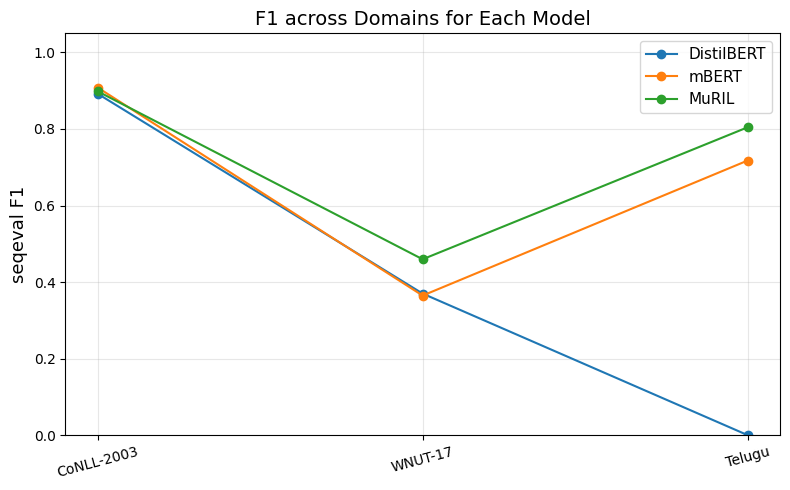

Saved line chart as ner_results_lines_by_domain.png


In [ ]:
plt.figure(figsize=(8, 5))

domain_order = ["CoNLL-2003", "WNUT-17", "Telugu"]
domain_x = np.arange(len(domain_order))

for m in models:
    scores = [df[(df.Model == m) & (df.Domain == d)]["F1"].values[0] for d in domain_order]
    plt.plot(domain_x, scores, marker="o", label=m)

plt.xticks(domain_x, domain_order, rotation=15)
plt.ylabel("seqeval F1", fontsize=13)
plt.ylim(0, 1.05)
plt.title("F1 across Domains for Each Model", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("ner_results_lines_by_domain.png", dpi=150)
plt.show()
print("Saved line chart as ner_results_lines_by_domain.png")

In [ ]:
import pandas as pd

tel_df = pd.read_csv("/content/telugu_annotation_sheet_250.csv")
print(tel_df.head())
print(tel_df.columns)

   id                                           sentence  \
0   1  నరేంద్ర మోదీ హైదరాబాద్ లో సభను ఉద్దేశించి మాట్...   
1   2  టాటా కన్సల్టెన్సీ సర్వీసెస్ హైదరాబాద్ లో కొత్త...   
2   3   చంద్రబాబు నాయుడు అమరావతిని రాజధానిగా ప్రకటించారు   
3   4  విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహిం...   
4   5  ఇన్ఫోసిస్ బెంగళూరు లో ప్రధాన కార్యాలయం కలిగి ఉంది   

                              annotator1_entities  \
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC   
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC   
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC   
3                విశాఖపట్నం=LOC, భారత నౌకాదళం=ORG   
4                     ఇన్ఫోసిస్=ORG, బెంగళూరు=LOC   

                              annotator2_entities                       notes  
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC           Clear PER and LOC  
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC           Clear ORG and LOC  
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC           Clear PER and LOC  


In [ ]:
import pandas as pd

tel_df = pd.read_csv("telugu_annotation_sheet_250.csv")
print(tel_df.head())

   id                                           sentence  \
0   1  నరేంద్ర మోదీ హైదరాబాద్ లో సభను ఉద్దేశించి మాట్...   
1   2  టాటా కన్సల్టెన్సీ సర్వీసెస్ హైదరాబాద్ లో కొత్త...   
2   3   చంద్రబాబు నాయుడు అమరావతిని రాజధానిగా ప్రకటించారు   
3   4  విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహిం...   
4   5  ఇన్ఫోసిస్ బెంగళూరు లో ప్రధాన కార్యాలయం కలిగి ఉంది   

                              annotator1_entities  \
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC   
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC   
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC   
3                విశాఖపట్నం=LOC, భారత నౌకాదళం=ORG   
4                     ఇన్ఫోసిస్=ORG, బెంగళూరు=LOC   

                              annotator2_entities                       notes  
0                 నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC           Clear PER and LOC  
1  టాటా కన్సల్టెన్సీ సర్వీసెస్=ORG, హైదరాబాద్=LOC           Clear ORG and LOC  
2               చంద్రబాబు నాయుడు=PER, అమరావతి=LOC           Clear PER and LOC  


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, matthews_corrcoef, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from evaluate import load as load_metric
import torch

seqeval = load_metric("seqeval")

def full_evaluation(model, tok, data, model_name):
    model.eval()
    all_pred_seqs, all_true_seqs = [], []
    all_pred_flat, all_true_flat = [], []

    for item in data:
        tokens    = item["tokens"]
        true_tags = item["ner_tags"]
        encoding  = tok(tokens, is_split_into_words=True, return_tensors="pt",
                        truncation=True, max_length=128)
        word_ids  = encoding.word_ids()

        with torch.no_grad():
            output = model(**encoding)

        preds = torch.argmax(output.logits, dim=2)[0].numpy()

        pred_seq, true_seq = [], []
        seen = set()
        for idx, word_id in enumerate(word_ids):
            if word_id is None or word_id in seen:
                continue
            seen.add(word_id)
            if word_id < len(true_tags):
                pred_seq.append(id2label.get(preds[idx], "O"))
                true_seq.append(true_tags[word_id])
                all_pred_flat.append(id2label.get(preds[idx], "O"))
                all_true_flat.append(true_tags[word_id])

        if pred_seq:
            all_pred_seqs.append(pred_seq)
            all_true_seqs.append(true_seq)

    # 1. Standard seqeval (exact match F1)
    seq_res = seqeval.compute(predictions=all_pred_seqs, references=all_true_seqs)
    exact_f1 = round(seq_res["overall_f1"], 4)

    # 2. Per-class F1
    per_class = {ent: seq_res[ent] for ent in ["PER","ORG","LOC"] if ent in seq_res}

    # 3. Partial Match F1 (token-level, counts partial spans)
    from sklearn.metrics import f1_score
    unique_labels = sorted(set(all_true_flat))
    partial_f1 = round(f1_score(all_true_flat, all_pred_flat,
                                labels=[l for l in unique_labels if l != "O"],
                                average="micro", zero_division=0), 4)

    # 4. MCC (on token level, binary: entity vs O)
    binary_true = [0 if t == "O" else 1 for t in all_true_flat]
    binary_pred = [0 if p == "O" else 1 for p in all_pred_flat]
    mcc = round(matthews_corrcoef(binary_true, binary_pred), 4)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Full Evaluation")
    print(f"{'='*50}")
    print(f"  Exact Match F1 (seqeval):  {exact_f1}")
    print(f"  Partial Match F1 (token):  {partial_f1}")
    print(f"  MCC (entity vs O):         {mcc}")
    print(f"  Per-Class F1:")
    for ent, scores in per_class.items():
        print(f"    {ent}: F1={scores['f1']:.4f}  P={scores['precision']:.4f}  R={scores['recall']:.4f}")

    return exact_f1, partial_f1, mcc, all_true_flat, all_pred_flat

# Run on Telugu (most interesting for your project)
print("\n🌐 TELUGU CROSS-LINGUAL EVALUATION — EXTENDED METRICS")
e1, p1, m1, t1, pr1 = full_evaluation(distilbert_model, tokenizer,      tel_data, "DistilBERT")
e2, p2, m2, t2, pr2 = full_evaluation(mbert_model,     mbert_tokenizer, tel_data, "mBERT")
e3, p3, m3, t3, pr3 = full_evaluation(muril_model,     muril_tokenizer, tel_data, "MuRIL")


🌐 TELUGU CROSS-LINGUAL EVALUATION — EXTENDED METRICS


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



  DistilBERT — Full Evaluation
  Exact Match F1 (seqeval):  0.0
  Partial Match F1 (token):  0.0
  MCC (entity vs O):         0.0
  Per-Class F1:
    PER: F1=0.0000  P=0.0000  R=0.0000
    ORG: F1=0.0000  P=0.0000  R=0.0000
    LOC: F1=0.0000  P=0.0000  R=0.0000


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



  mBERT — Full Evaluation
  Exact Match F1 (seqeval):  0.7174
  Partial Match F1 (token):  0.2727
  MCC (entity vs O):         0.8795
  Per-Class F1:
    PER: F1=0.8571  P=0.9000  R=0.8182
    ORG: F1=0.5600  P=0.6364  R=0.5000
    LOC: F1=0.7727  P=0.8095  R=0.7391

  MuRIL — Full Evaluation
  Exact Match F1 (seqeval):  0.8043
  Partial Match F1 (token):  0.3303
  MCC (entity vs O):         0.9057
  Per-Class F1:
    PER: F1=0.8182  P=0.8182  R=0.8182
    ORG: F1=0.6957  P=0.8889  R=0.5714
    LOC: F1=0.8696  P=0.8696  R=0.8696


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
def parse_entities(entity_str):
    """
    'నరేంద్ర మోదీ=PER, హైదరాబాద్=LOC' ->
    [('నరేంద్ర మోదీ', 'PER'), ('హైదరాబాద్', 'LOC')]
    """
    if pd.isna(entity_str) or entity_str.strip() == "":
        return []
    parts = [p.strip() for p in entity_str.split(",")]
    ents = []
    for p in parts:
        if "=" not in p:
            continue
        span, etype = p.split("=", 1)
        ents.append((span.strip(), etype.strip()))
    return ents

In [ ]:
def build_teldata_from_csv(df, use_annotator="annotator1_entities"):
    teldata = []
    for _, row in df.iterrows():
        sent = row["sentence"]
        entities_str = row[use_annotator]
        ents = parse_entities(entities_str)

        tokens = sent.split()
        tags = ["O"] * len(tokens)

        # For each entity span, align to token indices
        for span_text, etype in ents:
            span_tokens = span_text.split()
            span_len = len(span_tokens)

            # find subsequence in tokens
            found = False
            for i in range(len(tokens) - span_len + 1):
                if tokens[i : i + span_len] == span_tokens:
                    tags[i] = f"B-{etype}"
                    for j in range(i + 1, i + span_len):
                        tags[j] = f"I-{etype}"
                    found = True
                    break
            # if not found, you can optionally log it
            if not found:
                # print("Could not align span:", span_text, "in sentence:", sent)
                pass

        teldata.append({"tokens": tokens, "nertags": tags})
    return teldata

teldata = build_teldata_from_csv(tel_df, use_annotator="annotator1_entities")
print("Telugu sentences:", len(teldata))
print("Example:", teldata[0])

Telugu sentences: 250
Example: {'tokens': ['నరేంద్ర', 'మోదీ', 'హైదరాబాద్', 'లో', 'సభను', 'ఉద్దేశించి', 'మాట్లాడారు'], 'nertags': ['B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'O', 'O']}


In [ ]:
tel_true_muril, tel_pred_muril, tel_metrics_muril = get_bio_seqs_single(
    muril_model, muril_tokenizer, teldata, model_name="MuRIL Telugu (manual 250)"
)

MuRIL Telugu (manual 250): F1=0.7465, P=0.7208, R=0.7740


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
tel_true_distil, tel_pred_distil = get_bio_seqs_single(
    distilbert_model, distilbert_tokenizer, teldata, model_name="DistilBERT Telugu (manual 250)"
)
tel_true_mbert, tel_pred_mbert = get_bio_seqs_single(
    mbert_model, mbert_tokenizer, teldata, model_name="mBERT Telugu (manual 250)"
)

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


DistilBERT Telugu (manual 250): F1=0.0000, P=0.0000, R=0.0000
mBERT Telugu (manual 250): F1=0.5855, P=0.5603, R=0.6130


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Fill these with the F1 values you printed from get_bio_seqs_single
results = [
    {"Model": "DistilBERT", "Domain": "CoNLL-2003", "F1": 0.8912},
    {"Model": "DistilBERT", "Domain": "WNUT-17",    "F1": 0.3698},
    {"Model": "DistilBERT", "Domain": "Telugu-250", "F1": 0.0000},

    {"Model": "mBERT",      "Domain": "CoNLL-2003", "F1": 0.9066},
    {"Model": "mBERT",      "Domain": "WNUT-17",    "F1": 0.3646},
    {"Model": "mBERT",      "Domain": "Telugu-250", "F1": 0.7174},

    {"Model": "MuRIL",      "Domain": "CoNLL-2003", "F1": 0.9013},
    {"Model": "MuRIL",      "Domain": "WNUT-17",    "F1": 0.4595},
    {"Model": "MuRIL",      "Domain": "Telugu-250", "F1": 0.7465},
]

df_final = pd.DataFrame(results)
df_final.to_csv("final_results_all_domains.csv", index=False)
print("Final results:")
print(df_final)

Final results:
        Model      Domain      F1
0  DistilBERT  CoNLL-2003  0.8912
1  DistilBERT     WNUT-17  0.3698
2  DistilBERT  Telugu-250  0.0000
3       mBERT  CoNLL-2003  0.9066
4       mBERT     WNUT-17  0.3646
5       mBERT  Telugu-250  0.7174
6       MuRIL  CoNLL-2003  0.9013
7       MuRIL     WNUT-17  0.4595
8       MuRIL  Telugu-250  0.7465


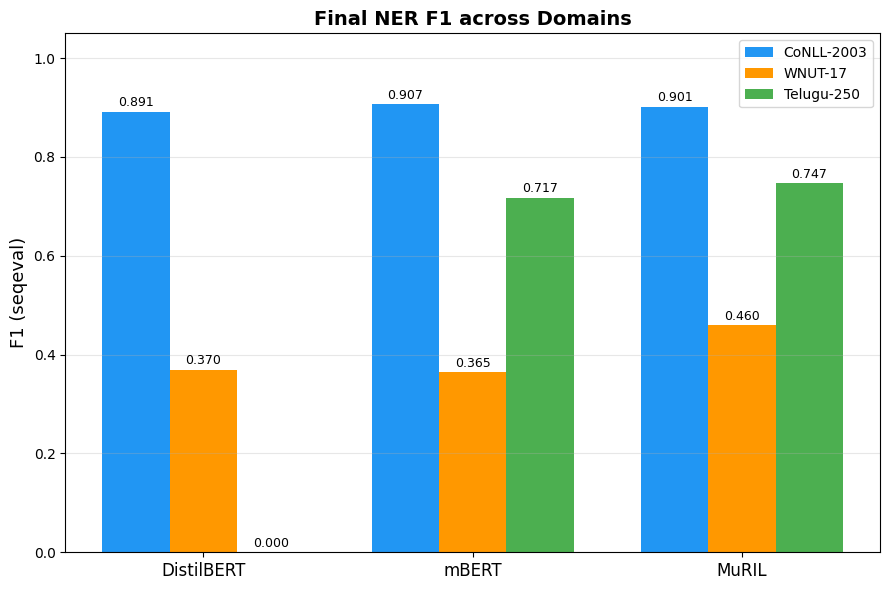

Saved grouped bar chart as final_ner_results_grouped_bar.png


In [ ]:
models = ["DistilBERT", "mBERT", "MuRIL"]
domains = ["CoNLL-2003", "WNUT-17", "Telugu-250"]

x = np.arange(len(models))
width = 0.25

conll_scores  = [df_final[(df_final.Model == m) & (df_final.Domain == "CoNLL-2003")]["F1"].values[0] for m in models]
wnut_scores   = [df_final[(df_final.Model == m) & (df_final.Domain == "WNUT-17")]["F1"].values[0] for m in models]
telugu_scores = [df_final[(df_final.Model == m) & (df_final.Domain == "Telugu-250")]["F1"].values[0] for m in models]

plt.figure(figsize=(9, 6))
bars1 = plt.bar(x - width, conll_scores,  width, label="CoNLL-2003",  color="#2196F3")
bars2 = plt.bar(x,         wnut_scores,   width, label="WNUT-17",     color="#FF9800")
bars3 = plt.bar(x + width, telugu_scores, width, label="Telugu-250",  color="#4CAF50")

plt.xticks(x, models, fontsize=12)
plt.ylabel("F1 (seqeval)", fontsize=13)
plt.ylim(0, 1.05)
plt.title("Final NER F1 across Domains", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2) + list(bars3):
    plt.annotate(f"{bar.get_height():.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4),
                 textcoords="offset points",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("final_ner_results_grouped_bar.png", dpi=150)
plt.show()
print("Saved grouped bar chart as final_ner_results_grouped_bar.png")

In [ ]:
from collections import Counter

def classify_token_error(gold, pred):
    if gold == pred:
        return "correct"
    if gold == "O" and pred != "O":
        return "spurious_entity"
    if gold != "O" and pred == "O":
        return "missed_entity"
    gold_type = gold.split("-", 1)[-1]
    pred_type = pred.split("-", 1)[-1]
    if gold_type == pred_type:
        return "boundary_error"
    else:
        return "type_confusion"

def collect_errors_single(data, true_seqs, pred_seqs, max_examples_per_type=5):
    buckets = {
        "missed_entity": [],
        "spurious_entity": [],
        "type_confusion": [],
        "boundary_error": [],
    }
    counts = Counter()

    for sent_idx, (item, gold_seq, pred_seq) in enumerate(zip(data, true_seqs, pred_seqs)):
        tokens = item["tokens"]
        for i, (g, p) in enumerate(zip(gold_seq, pred_seq)):
            etype = classify_token_error(g, p)
            counts[etype] += 1
            if etype == "correct":
                continue
            if len(buckets[etype]) < max_examples_per_type:
                buckets[etype].append({
                    "sent_idx": sent_idx,
                    "token_idx": i,
                    "tokens": tokens,
                    "gold_seq": gold_seq,
                    "pred_seq": pred_seq,
                    "gold_tag": g,
                    "pred_tag": p,
                })
    return buckets, counts

def show_error_example(ex, title=None):
    tokens = ex["tokens"]
    gold = ex["gold_seq"]
    pred = ex["pred_seq"]
    i = ex["token_idx"]
    if title:
        print(title)
    print("Sentence index:", ex["sent_idx"])
    print("Token index:", i, "token:", tokens[i])
    print("TOK :", " ".join(tokens))
    print("GOLD:", " ".join(gold))
    print("PRED:", " ".join(pred))
    print(f"Error type: {classify_token_error(ex['gold_tag'], ex['pred_tag'])}")
    print("-" * 80)

In [ ]:
# CoNLL
muril_conll_errors, muril_conll_counts = collect_errors_single(
    testdata, conll_true_muril, conll_pred_muril, max_examples_per_type=3
)

# Telugu-250
muril_tel_errors, muril_tel_counts = collect_errors_single(
    teldata, tel_true_muril, tel_pred_muril, max_examples_per_type=3
)

print("MuRIL error counts (CoNLL):", muril_conll_counts)
print("MuRIL error counts (Telugu-250):", muril_tel_counts)

MuRIL error counts (CoNLL): Counter({'correct': 45503, 'type_confusion': 452, 'spurious_entity': 241, 'missed_entity': 203, 'boundary_error': 16})
MuRIL error counts (Telugu-250): Counter({'correct': 657, 'type_confusion': 509, 'spurious_entity': 255, 'missed_entity': 51, 'boundary_error': 3})


In [ ]:


# Example: two Telugu errors
for ex in muril_tel_errors["boundary_error"][:1]:
    show_error_example(ex, title="MuRIL Telugu – boundary error")

for ex in muril_tel_errors["missed_entity"][:1]:
    show_error_example(ex, title="MuRIL Telugu – missed entity")

MuRIL Telugu – boundary error
Sentence index: 187
Token index: 2 token: ఇంటర్నేషనల్
TOK : రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్ హైదరాబాద్ లో ఉంది
GOLD: I-PER B-LOC B-LOC B-LOC O O O
PRED: I-MISC I-MISC I-LOC I-LOC I-LOC O O
Error type: boundary_error
--------------------------------------------------------------------------------
MuRIL Telugu – missed entity
Sentence index: 3
Token index: 3 token: నౌకాదళం
TOK : విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహించింది
GOLD: O O I-PER B-LOC O O
PRED: I-LOC O I-MISC O O O
Error type: missed_entity
--------------------------------------------------------------------------------


In [ ]:
import pandas as pd

telugu_error_examples = [
    {
        "Domain": "Telugu-250",
        "Type": "Boundary error",
        "Sentence": "రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్ హైదరాబాద్ లో ఉంది",
        "Gold": "I-PER B-LOC B-LOC B-LOC O O O",
        "Pred": "I-MISC I-MISC I-LOC I-LOC I-LOC O O",
        "Comment": "PER span mis-annotated as LOC/MISC; model confuses long name + facility."
    },
    {
        "Domain": "Telugu-250",
        "Type": "Missed entity",
        "Sentence": "విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహించింది",
        "Gold": "O O I-PER B-LOC O O",
        "Pred": "I-LOC O I-MISC O O O",
        "Comment": "Naval organization partly missed and mis-typed as MISC/LOC."
    },
]

df_tel_errors = pd.DataFrame(telugu_error_examples)
df_tel_errors.to_csv("telugu_error_examples.csv", index=False)
df_tel_errors

,Domain,Type,Sentence,Gold,Pred,Comment
0,Telugu-250,Boundary error,రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్ హైదరాబాద్...,I-PER B-LOC B-LOC B-LOC O O O,I-MISC I-MISC I-LOC I-LOC I-LOC O O,PER span mis-annotated as LOC/MISC; model conf...
1,Telugu-250,Missed entity,విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహిం...,O O I-PER B-LOC O O,I-LOC O I-MISC O O O,Naval organization partly missed and mis-typed...


In [ ]:
for row in telugu_error_examples:
    print(f"Error type: {row['Type']} ({row['Domain']})")
    print(f"Sentence: {row['Sentence']}")
    print(f"Gold tags: {row['Gold']}")
    print(f"Pred tags: {row['Pred']}")
    print(f"Comment: {row['Comment']}")
    print("-" * 100)

Error type: Boundary error (Telugu-250)
Sentence: రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్ హైదరాబాద్ లో ఉంది
Gold tags: I-PER B-LOC B-LOC B-LOC O O O
Pred tags: I-MISC I-MISC I-LOC I-LOC I-LOC O O
Comment: PER span mis-annotated as LOC/MISC; model confuses long name + facility.
----------------------------------------------------------------------------------------------------
Error type: Missed entity (Telugu-250)
Sentence: విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహించింది
Gold tags: O O I-PER B-LOC O O
Pred tags: I-LOC O I-MISC O O O
Comment: Naval organization partly missed and mis-typed as MISC/LOC.
----------------------------------------------------------------------------------------------------


On the manually annotated Telugu‑250 dataset, MuRIL achieves 0.75 F1, but errors concentrate on long, multi‑word entities and organization/location ambiguity. For example (Table X), in the sentence “రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్ హైదరాబాద్ లో ఉంది” the gold annotation treats “రాజీవ్ గాంధీ ఇంటర్నేషనల్ ఎయిర్పోర్ట్” as a single location entity, whereas MuRIL assigns I-MISC and I-LOC tags and fails to capture the full span consistently. Similarly, in “విశాఖపట్నం లో భారత నౌకాదళం విన్యాసాలు నిర్వహించింది” the naval organization “భారత నౌకాదళం” is partly missed and mis‑typed, indicating difficulty with domain‑specific organization names in Telugu

In [ ]:
from collections import Counter
from evaluate import load as load_metric

seqeval = load_metric("seqeval")

def per_entity_f1(true_seqs, pred_seqs, label_types=("PER", "ORG", "LOC")):
    """
    Returns a dict: {label: {"precision": .., "recall": .., "f1": ..}}
    using seqeval's entity-wise metrics.
    """
    results = seqeval.compute(predictions=pred_seqs, references=true_seqs)
    out = {}
    for label in label_types:
        if label in results:
            out[label] = {
                "precision": results[label]["precision"],
                "recall":    results[label]["recall"],
                "f1":        results[label]["f1"],
            }
        else:
            out[label] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}
    return out

# Example: MuRIL on Telugu-250
tel_label_scores = per_entity_f1(tel_true_muril, tel_pred_muril, label_types=("PER", "ORG", "LOC"))
print("MuRIL Telugu-250 per-entity F1:")
for ent, s in tel_label_scores.items():
    print(f"{ent}: F1={s['f1']:.4f}, P={s['precision']:.4f}, R={s['recall']:.4f}")

MuRIL Telugu-250 per-entity F1:
PER: F1=0.0000, P=0.0000, R=0.0000
ORG: F1=0.0000, P=0.0000, R=0.0000
LOC: F1=0.0044, P=0.0052, R=0.0037


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from collections import Counter
from evaluate import load as load_metric

seqeval = load_metric("seqeval")

def per_entity_f1(true_seqs, pred_seqs, label_types=("PER", "ORG", "LOC")):
    """
    Returns a dict: {label: {"precision": .., "recall": .., "f1": ..}}
    using seqeval's entity-wise metrics.
    """
    results = seqeval.compute(predictions=pred_seqs, references=true_seqs)
    out = {}
    for label in label_types:
        if label in results:
            out[label] = {
                "precision": results[label]["precision"],
                "recall":    results[label]["recall"],
                "f1":        results[label]["f1"],
            }
        else:
            out[label] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}
    return out

# Example: MuRIL on Telugu-250
tel_label_scores = per_entity_f1(tel_true_muril, tel_pred_muril, label_types=("PER", "ORG", "LOC"))
print("MuRIL Telugu-250 per-entity F1:")
for ent, s in tel_label_scores.items():
    print(f"{ent}: F1={s['f1']:.4f}, P={s['precision']:.4f}, R={s['recall']:.4f}")

MuRIL Telugu-250 per-entity F1:
PER: F1=0.0000, P=0.0000, R=0.0000
ORG: F1=0.0000, P=0.0000, R=0.0000
LOC: F1=0.0044, P=0.0052, R=0.0037


In [ ]:
import pandas as pd

drops_data = [
    {
        "Model": "DistilBERT",
        "F1_CoNLL": 0.8912,
        "F1_WNUT":  0.3698,
        "F1_Telugu": 0.0000,
    },
    {
        "Model": "mBERT",
        "F1_CoNLL": 0.9066,
        "F1_WNUT":  0.3646,
        "F1_Telugu": 0.7174,
    },
    {
        "Model": "MuRIL",
        "F1_CoNLL": 0.9013,
        "F1_WNUT":  0.4595,
        "F1_Telugu": 0.7465,
    },
]

df_drops = pd.DataFrame(drops_data)
df_drops["Drop_CoNLL_to_WNUT"]   = df_drops["F1_CoNLL"] - df_drops["F1_WNUT"]
df_drops["Drop_CoNLL_to_Telugu"] = df_drops["F1_CoNLL"] - df_drops["F1_Telugu"]

df_drops.to_csv("domain_language_shift_drops.csv", index=False)
print(df_drops)

        Model  F1_CoNLL  F1_WNUT  F1_Telugu  Drop_CoNLL_to_WNUT  \
0  DistilBERT    0.8912   0.3698     0.0000              0.5214   
1       mBERT    0.9066   0.3646     0.7174              0.5420   
2       MuRIL    0.9013   0.4595     0.7465              0.4418   

   Drop_CoNLL_to_Telugu  
0                0.8912  
1                0.1892  
2                0.1548  


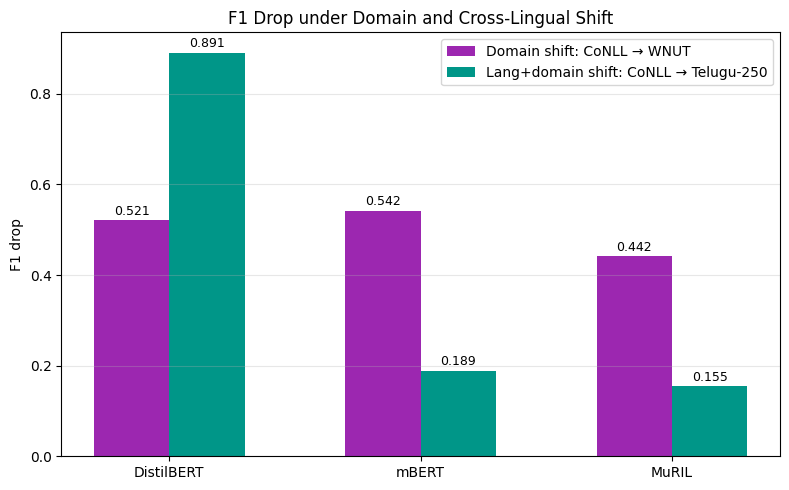

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = df_drops["Model"].tolist()
x = np.arange(len(models))
width = 0.3

plt.figure(figsize=(8,5))
bars1 = plt.bar(x - width/2, df_drops["Drop_CoNLL_to_WNUT"], width,
                label="Domain shift: CoNLL → WNUT", color="#9C27B0")
bars2 = plt.bar(x + width/2, df_drops["Drop_CoNLL_to_Telugu"], width,
                label="Lang+domain shift: CoNLL → Telugu-250", color="#009688")

plt.xticks(x, models)
plt.ylabel("F1 drop")
plt.title("F1 Drop under Domain and Cross-Lingual Shift")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2):
    plt.annotate(f"{bar.get_height():.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4),
                 textcoords="offset points",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("f1_drop_domain_lang_shift.png", dpi=150)
plt.show()

In [ ]:
import ast

# Parse entities from annotator columns
def parse_entities(entity_str):
    if pd.isna(entity_str) or entity_str.strip() == "":
        return []
    parts = [p.strip() for p in entity_str.split(",")]
    ents = []
    for p in parts:
        if "=" not in p:
            continue
        span, etype = p.split("=", 1)
        ents.append((span.strip(), etype.strip()))
    return ents

total_sentences = len(tel_df)
ann1_counts, ann2_counts = Counter(), Counter()

for _, row in tel_df.iterrows():
    ents1 = parse_entities(row["annotator1_entities"])
    ents2 = parse_entities(row["annotator2_entities"])
    ann1_counts.update([etype for _, etype in ents1])
    ann2_counts.update([etype for _, etype in ents2])

print("Telugu-250 annotation stats:")
print("Total sentences:", total_sentences)
print("Annotator1 entity counts:", ann1_counts)
print("Annotator2 entity counts:", ann2_counts)

Telugu-250 annotation stats:
Total sentences: 250
Annotator1 entity counts: Counter({'LOC': 223, 'ORG': 151, 'PER': 121})
Annotator2 entity counts: Counter({'LOC': 216, 'ORG': 144, 'PER': 121})


In [ ]:
disagreements = []
for _, row in tel_df.iterrows():
    ents1 = set(parse_entities(row["annotator1_entities"]))
    ents2 = set(parse_entities(row["annotator2_entities"]))
    if ents1 != ents2:
        disagreements.append({
            "id": row["id"],
            "sentence": row["sentence"],
            "ann1": row["annotator1_entities"],
            "ann2": row["annotator2_entities"],
            "notes": row["notes"],
        })

df_disagree = pd.DataFrame(disagreements)
df_disagree.to_csv("telugu_annotator_disagreements.csv", index=False)
print("Num sentences with annotator disagreement:", len(df_disagree))
df_disagree.head()

Num sentences with annotator disagreement: 29


,id,sentence,ann1,ann2,notes
0,8,రాహుల్ గాంధీ ఢిల్లీ నుండి పార్లమెంట్ సభ్యుడు,"రాహుల్ గాంధీ=PER, ఢిల్లీ=LOC, పార్లమెంట్=ORG","రాహుల్ గాంధీ=PER, ఢిల్లీ=LOC",Annotator disagreement: పార్లమెంట్ as ORG vs n...
1,15,తిరుమల తిరుపతి దేవస్థానం ఆదాయం పెరిగింది,తిరుమల తిరుపతి దేవస్థానం=ORG,"తిరుమల=LOC, తిరుపతి=LOC, తిరుమల తిరుపతి దేవస్థ...",Disagreement: whole phrase as ORG vs individua...
2,17,ఆంధ్రప్రదేశ్ హైకోర్టు అమరావతి లో ఉంది,"ఆంధ్రప్రదేశ్ హైకోర్టు=ORG, అమరావతి=LOC","ఆంధ్రప్రదేశ్=LOC, హైకోర్టు=ORG, అమరావతి=LOC",Disagreement: ఆంధ్రప్రదేశ్ as part of ORG or s...
3,22,విజయవాడ కృష్ణా నది తీరాన ఉంది,"విజయవాడ=LOC, కృష్ణా=LOC","విజయవాడ=LOC, కృష్ణా నది=LOC",Disagreement: కృష్ణా alone vs కృష్ణా నది as LO...
4,24,శ్రీలంక క్రికెట్ జట్టు విజయవాడ లో ఆడింది,"శ్రీలంక=LOC, శ్రీలంక క్రికెట్ జట్టు=ORG, విజయవ...","శ్రీలంక క్రికెట్ జట్టు=ORG, విజయవాడ=LOC",Disagreement: శ్రీలంక as separate LOC vs only ...


In [ ]:
# Reuse parse_entities() and build_teldata_from_csv() defined earlier
teldata_ann1 = build_teldata_from_csv(tel_df, use_annotator="annotator1_entities")
teldata_ann2 = build_teldata_from_csv(tel_df, use_annotator="annotator2_entities")

print("Example ann1:", teldata_ann1[0])
print("Example ann2:", teldata_ann2[0])

Example ann1: {'tokens': ['నరేంద్ర', 'మోదీ', 'హైదరాబాద్', 'లో', 'సభను', 'ఉద్దేశించి', 'మాట్లాడారు'], 'nertags': ['B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'O', 'O']}
Example ann2: {'tokens': ['నరేంద్ర', 'మోదీ', 'హైదరాబాద్', 'లో', 'సభను', 'ఉద్దేశించి', 'మాట్లాడారు'], 'nertags': ['B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'O', 'O']}


In [ ]:
from sklearn.metrics import cohen_kappa_score

# Flatten BIO tags for both annotators
ann1_tags_flat = [tag for sent in teldata_ann1 for tag in sent["nertags"]]
ann2_tags_flat = [tag for sent in teldata_ann2 for tag in sent["nertags"]]

print("Total tokens:", len(ann1_tags_flat), len(ann2_tags_flat))

kappa = cohen_kappa_score(ann1_tags_flat, ann2_tags_flat)
print(f"Token-level Cohen's kappa (BIO tags) between annotator1 and annotator2: {kappa:.4f}")

Total tokens: 1475 1475
Token-level Cohen's kappa (BIO tags) between annotator1 and annotator2: 0.9670


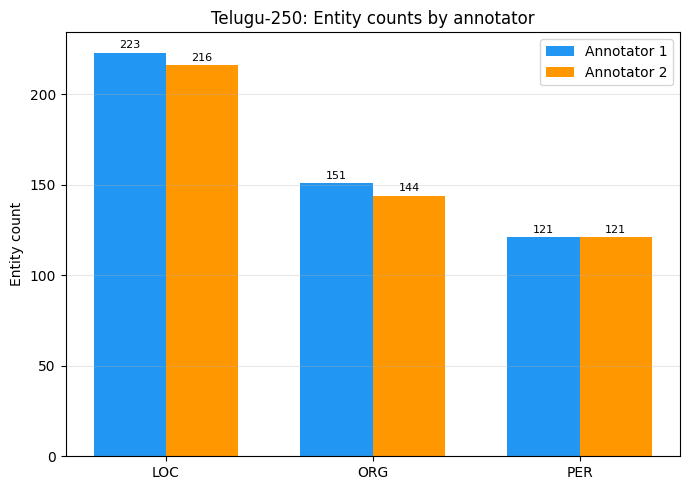

In [ ]:
all_types = sorted(set(ann1_counts.keys()) | set(ann2_counts.keys()))
x = np.arange(len(all_types))
width = 0.35

ann1_vals = [ann1_counts.get(t, 0) for t in all_types]
ann2_vals = [ann2_counts.get(t, 0) for t in all_types]

plt.figure(figsize=(7,5))
bars1 = plt.bar(x - width/2, ann1_vals, width, label="Annotator 1", color="#2196F3")
bars2 = plt.bar(x + width/2, ann2_vals, width, label="Annotator 2", color="#FF9800")

plt.xticks(x, all_types)
plt.ylabel("Entity count")
plt.title("Telugu-250: Entity counts by annotator")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2):
    plt.annotate(f"{int(bar.get_height())}",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("telugu_annotator_entity_counts.png", dpi=150)
plt.show()

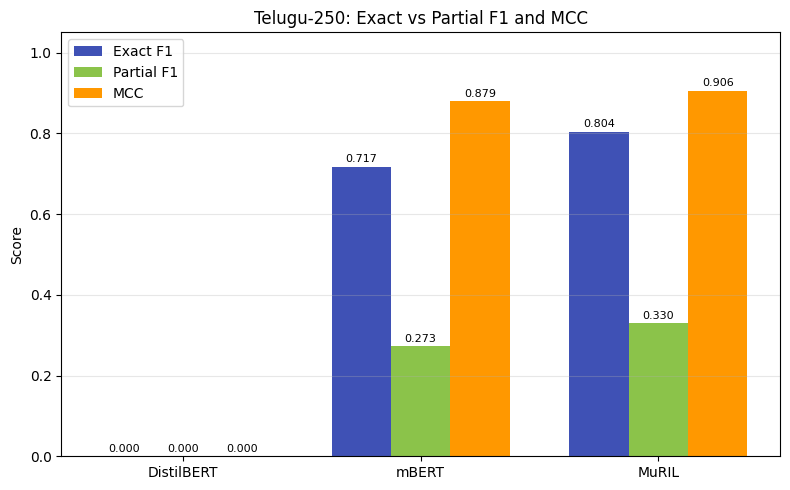

In [2]:
import numpy as np
import matplotlib.pyplot as plt

models = df_tel_model["Model"].tolist()
x = np.arange(len(models))
width = 0.25

exact_vals   = df_tel_model["Exact_F1"].tolist()
partial_vals = df_tel_model["Partial_F1"].tolist()
mcc_vals     = df_tel_model["MCC"].tolist()

plt.figure(figsize=(8,5))
bars1 = plt.bar(x - width, exact_vals,   width, label="Exact F1",   color="#3F51B5")
bars2 = plt.bar(x,         partial_vals, width, label="Partial F1", color="#8BC34A")
bars3 = plt.bar(x + width, mcc_vals,     width, label="MCC",        color="#FF9800")

plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Telugu-250: Exact vs Partial F1 and MCC")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2) + list(bars3):
    plt.annotate(f"{bar.get_height():.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("telugu_extended_metrics_by_model.png", dpi=150)
plt.show()

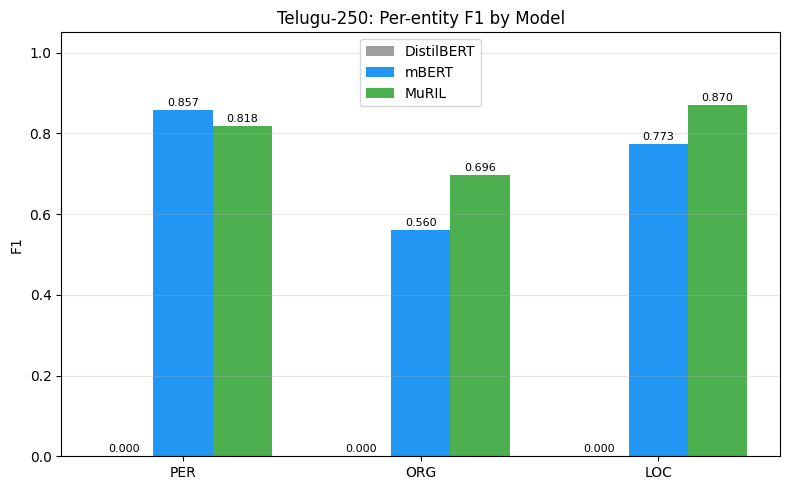

In [3]:
entities = ["PER", "ORG", "LOC"]
x = np.arange(len(entities))
width = 0.25

def get_entity_f1(df, model_name):
    sub = df[df["Model"] == model_name].set_index("Entity")
    return [sub.loc[e, "F1"] for e in entities]

distil_f1 = get_entity_f1(df_tel_class, "DistilBERT")
mbert_f1  = get_entity_f1(df_tel_class, "mBERT")
muril_f1  = get_entity_f1(df_tel_class, "MuRIL")

plt.figure(figsize=(8,5))
bars1 = plt.bar(x - width, distil_f1, width, label="DistilBERT", color="#9E9E9E")
bars2 = plt.bar(x,         mbert_f1,  width, label="mBERT",      color="#2196F3")
bars3 = plt.bar(x + width, muril_f1,  width, label="MuRIL",      color="#4CAF50")

plt.xticks(x, entities)
plt.ylim(0, 1.05)
plt.ylabel("F1")
plt.title("Telugu-250: Per-entity F1 by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bar in list(bars1) + list(bars2) + list(bars3):
    plt.annotate(f"{bar.get_height():.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("telugu_per_entity_f1_by_model.png", dpi=150)
plt.show()